In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle_day_month
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame, start_date: str):
    df = data.copy()
    df = df.asfreq('D')
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(y_true, y_pred, title="Прогноз vs Истинные значения"):
    """
    Строит график сравнения истинных значений и прогноза
    """
    plt.figure(figsize=(12, 5))
    
    plt.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    plt.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
start_date = '2020-11-27'

df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full, start_date)
df_train = process_data(df_train, start_date)
df_val = process_data(df_val, start_date)
df_test = process_data(df_test, start_date)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [7]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:24:54,641] A new study created in memory with name: no-name-f30ed9ae-a5ee-47a3-9ac0-1613aa154d4f
[I 2026-05-10 17:24:56,117] Trial 0 finished with value: 5.6638582176325905 and parameters: {'lags': 4, 'n_estimators': 1450, 'learning_rate': 0.04502046490451849, 'max_depth': 9, 'subsample': 0.7426371999371468, 'colsample_bytree': 0.7590955929385235, 'colsample_bylevel': 0.8794221334172869, 'colsample_bynode': 0.810472936347535, 'reg_alpha': 2.0453148852641043e-09, 'reg_lambda': 18.23672379182014, 'gamma': 2.1153726693311146e-05, 'min_child_weight': 4, 'max_delta_step': 14}. Best is trial 0 with value: 5.6638582176325905.
[I 2026-05-10 17:24:56,406] Trial 1 finished with value: 8.618696118126788 and parameters: {'lags': 1, 'n_estimators': 575, 'learning_rate': 0.0008349605456409652, 'max_depth': 9, 'subsample': 0.5850671534867032, 'colsample_bytree': 0.4122155246290109, 'colsample_bylevel': 0.4578515920571945, 'colsample_bynode': 0.4074821522358297, 'reg_alpha': 0.0088429

Лучшие параметры = {'lags': 1, 'n_estimators': 1319, 'learning_rate': 0.1038031927673289, 'max_depth': 1, 'subsample': 0.44942993491349637, 'colsample_bytree': 0.9661017938142957, 'colsample_bylevel': 0.8459537689678344, 'colsample_bynode': 0.7787126170778413, 'reg_alpha': 3.038921009013122e-06, 'reg_lambda': 3.4925092470695226e-09, 'gamma': 1.8056682643549973e-08, 'min_child_weight': 28, 'max_delta_step': 5}
Лучший RMSE score = 2.4839008103502525


Глубина 5

In [10]:
depth = 5
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [11]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:30:26,120] A new study created in memory with name: no-name-bb26450e-85a7-44e6-839d-ab659ea89696
[I 2026-05-10 17:30:26,618] Trial 0 finished with value: 1.4384770146794574 and parameters: {'lags': 2, 'n_estimators': 940, 'learning_rate': 0.00512650324382059, 'max_depth': 10, 'subsample': 0.8518102203282996, 'colsample_bytree': 0.6447778074909352, 'colsample_bylevel': 0.6916646572738346, 'colsample_bynode': 0.8279197222934057, 'reg_alpha': 7.663864263070117e-07, 'reg_lambda': 8.436168399382797e-06, 'gamma': 8.08790931211846e-06, 'min_child_weight': 20, 'max_delta_step': 2}. Best is trial 0 with value: 1.4384770146794574.
[I 2026-05-10 17:30:26,954] Trial 1 finished with value: 1.796538807014606 and parameters: {'lags': 4, 'n_estimators': 1096, 'learning_rate': 0.0018395698810692645, 'max_depth': 5, 'subsample': 0.46337762691443757, 'colsample_bytree': 0.4595369444772699, 'colsample_bylevel': 0.8066545876906855, 'colsample_bynode': 0.8716030519784702, 'reg_alpha': 0.000

Лучшие параметры = {'lags': 4, 'n_estimators': 1293, 'learning_rate': 0.009413785814721784, 'max_depth': 2, 'subsample': 0.9538867035244405, 'colsample_bytree': 0.9384323286888774, 'colsample_bylevel': 0.6604120679733316, 'colsample_bynode': 0.7667575882284428, 'reg_alpha': 2.534551802168295, 'reg_lambda': 4.975978184209794e-08, 'gamma': 4.349240819831622e-05, 'min_child_weight': 6, 'max_delta_step': 5}
Лучший RMSE score = 0.46942866580374254


Глубина 10

In [15]:
depth = 10
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [16]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 17:38:55,966] A new study created in memory with name: no-name-65abfb25-fe30-4533-af21-59374ca71b6a
[I 2026-05-10 17:38:56,225] Trial 0 finished with value: 0.6264241673341898 and parameters: {'lags': 1, 'n_estimators': 1241, 'learning_rate': 0.05814315281505205, 'max_depth': 5, 'subsample': 0.7733784851968726, 'colsample_bytree': 0.6886273499839684, 'colsample_bylevel': 0.665235331530561, 'colsample_bynode': 0.5162668047588868, 'reg_alpha': 0.3428739085015806, 'reg_lambda': 0.010325122159804467, 'gamma': 0.004125096547921929, 'min_child_weight': 13, 'max_delta_step': 8}. Best is trial 0 with value: 0.6264241673341898.
[I 2026-05-10 17:38:56,744] Trial 1 finished with value: 0.5932039148859025 and parameters: {'lags': 1, 'n_estimators': 1229, 'learning_rate': 0.006691771515197409, 'max_depth': 13, 'subsample': 0.5770603645999871, 'colsample_bytree': 0.8989821047635145, 'colsample_bylevel': 0.7403941591346271, 'colsample_bynode': 0.8220853807053516, 'reg_alpha': 5.83957472

Лучшие параметры = {'lags': 4, 'n_estimators': 655, 'learning_rate': 0.20441690353378553, 'max_depth': 10, 'subsample': 0.7277475735617176, 'colsample_bytree': 0.752896384226664, 'colsample_bylevel': 0.47172050515772307, 'colsample_bynode': 0.47977597139460476, 'reg_alpha': 0.010143897540507723, 'reg_lambda': 31.29260673216412, 'gamma': 0.0015882883413838624, 'min_child_weight': 14, 'max_delta_step': 17}
Лучший RMSE score = 0.21719132257279736


In [17]:
best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
best_model.fit(
            y=df_train_full[target_col],
            exog=df_train_full[exog_cols],
        )

joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_10']

RMSE на тесте = 0.3338856549063663


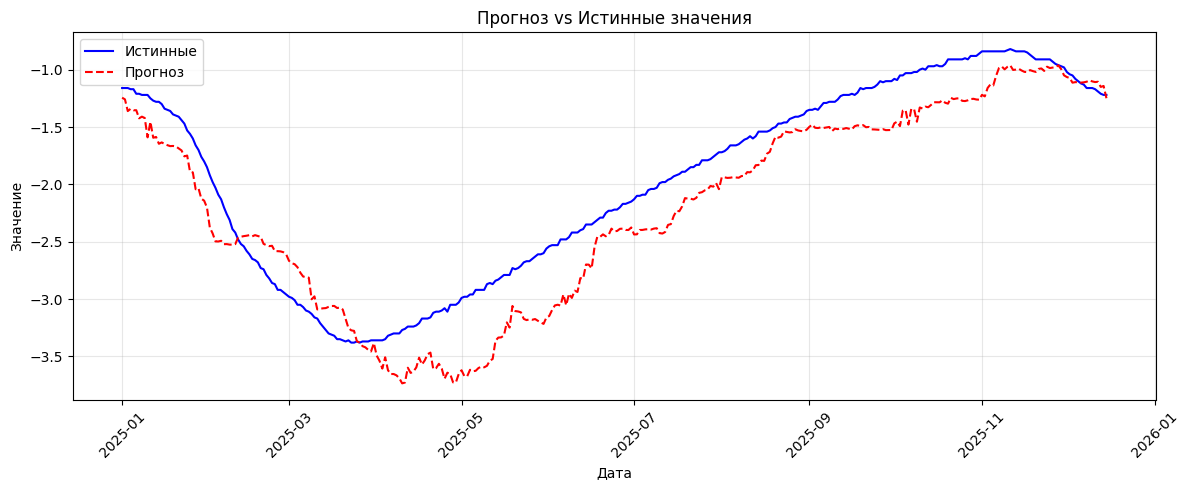

In [18]:
model = joblib.load(model_path)
#last_window = df_train_full[target_col].iloc[-len(model.lags):]
y_pred = model.predict(
            steps=len(df_test),
            exog=df_test[exog_cols]
        )

rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
print(f'RMSE на тесте = {rmse}')

plot_forecast(df_test[target_col], y_pred)

In [19]:
importances = model.get_feature_importances()
importances

,feature,importance
4,Месяц_sin,0.362287
1,lag_2,0.286072
2,lag_3,0.217459
0,lag_1,0.058181
3,lag_4,0.034302
5,Месяц_cos,0.021976
8,days_from_start,0.016968
6,День_sin,0.001513
7,День_cos,0.001243
